# Shapash + Keras in Jupyter: Titanic Survival Classification

This tutorial shows how to:
- train a tabular deep learning model (Keras)
- predict Titanic passenger survival
- explain predictions in a notebook with Shapash

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

from category_encoders import one_hot
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

import keras
from keras import layers

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading

## 2. Loading the Titanic data

In [2]:
titanic_df, titanic_dict = data_loading('titanic')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,,
1,0,Third class,Braund Owen Harris,male,22.0,1,0,7.25,Southampton,Mr
2,1,First class,Cumings John Bradley (Florence Briggs Thayer),female,38.0,1,0,71.28,Cherbourg,Mrs
3,1,Third class,Heikkinen Laina,female,26.0,0,0,7.92,Southampton,Miss
4,1,First class,Futrelle Jacques Heath (Lily May Peel),female,35.0,1,0,53.10,Southampton,Mrs
5,0,Third class,Allen William Henry,male,35.0,0,0,8.05,Southampton,Mr


In [3]:
features = ['Pclass', 'Age', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

df = titanic_df[features + [target]].copy()

# Convert Pclass labels to ordinal values
pclass_map = {
    'First class': 1,
    'Second class': 2,
    'Third class': 3,
}
df['Pclass'] = df['Pclass'].map(pclass_map).fillna(df['Pclass'])
df['Pclass'] = pd.to_numeric(df['Pclass'], errors='coerce')

# Clean minimal values for a tabular neural network
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Pclass'] = df['Pclass'].fillna(df['Pclass'].median())

X = df[features]
y = df[target].astype(int).to_frame()

X.shape, y.shape

((891, 7), (891, 1))

## 3. Encoding categorical variables

In [4]:
encoder = one_hot.OneHotEncoder(cols=['Sex', 'Embarked'], use_cat_names=True)
X_enc = encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((668, 10), (223, 10))

## 4. Deep learning model with Keras

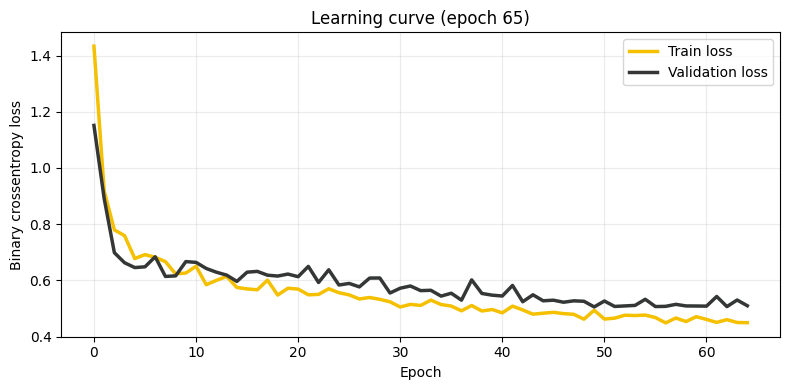

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7979 - loss: 0.4499 - val_accuracy: 0.7803 - val_loss: 0.5101
Best val_accuracy: 0.7937


In [5]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

SHAPASH_YELLOW = '#f4c000'
SHAPASH_GREY = '#343736'

class LiveLossPlot(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.train_losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(self.train_losses, label='Train loss', color=SHAPASH_YELLOW, linewidth=2.5)
        ax.plot(self.val_losses, label='Validation loss', color=SHAPASH_GREY, linewidth=2.5)
        ax.set_title(f'Learning curve (epoch {epoch + 1})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Binary crossentropy loss')
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

live_plot = LiveLossPlot()

history = model.fit(
    X_train.values,
    y_train.values,
    validation_data=(X_test.values, y_test.values),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, live_plot],
    # verbose=0
)
# load the best model weights from early stopping
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

In [6]:
proba_test = model.predict(X_test.values, verbose=0).reshape(-1)
pred_test = (proba_test >= 0.5).astype(int)

print(f"Test accuracy: {accuracy_score(y_test.values.reshape(-1), pred_test):.4f}")
print(classification_report(y_test.values.reshape(-1), pred_test, digits=4))

Test accuracy: 0.7892
              precision    recall  f1-score   support

           0     0.8082    0.8613    0.8339       137
           1     0.7532    0.6744    0.7117        86

    accuracy                         0.7892       223
   macro avg     0.7807    0.7679    0.7728       223
weighted avg     0.7870    0.7892    0.7868       223



## 5. Sklearn-like wrapper for Shapash

Shapash detects classification with the `classes_` and `predict_proba` attributes.
We add a lightweight wrapper around the Keras model.

In [7]:
class KerasBinaryClassifierWrapper:
    def __init__(self, keras_model, threshold=0.5):
        self.keras_model = keras_model
        self.threshold = threshold
        self.classes_ = np.array([0, 1])
        self._classes = [0, 1]

    def predict_proba(self, X):
        p1 = self.keras_model.predict(np.asarray(X), verbose=0).reshape(-1)
        p0 = 1.0 - p1
        return np.column_stack([p0, p1])

    def predict(self, X):
        p1 = self.predict_proba(X)[:, 1]
        return (p1 >= self.threshold).astype(int)

wrapped_model = KerasBinaryClassifierWrapper(keras_model=model, threshold=0.5)

## 6. Compiling SmartExplainer

We use the `shap` backend here to keep computation time reasonable for a tabular deep learning model.

In [8]:
# Keep explanation runtime low for a notebook demo
n_explain = min(200, len(X_test))
X_explain = X_test.sample(n=n_explain, random_state=42)
y_target_explain = y_test.loc[X_explain.index]

y_pred = pd.DataFrame(
    wrapped_model.predict(X_explain),
    index=X_explain.index,
    columns=['Survived']
)

response_dict = {0: 'Deceased', 1: 'Survived'}

xpl = SmartExplainer(
    model=wrapped_model,
    preprocessing=encoder,
    features_dict=titanic_dict,
    label_dict=response_dict,
    backend='shap',
    title_story='Titanic survival with a Keras'
)

xpl.compile(
    x=X_explain,
    y_pred=y_pred,
    y_target=y_target_explain
)

INFO: Shap explainer type - <shap.explainers._exact.ExactExplainer object at 0x12e970440>


ExactExplainer explainer: 201it [00:55,  3.10it/s]                         


## 7. Shapash plots in the notebook

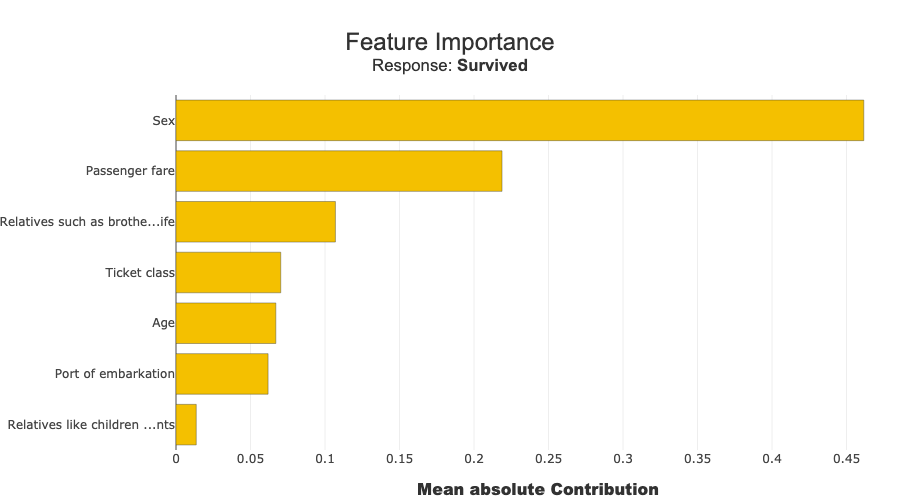

In [9]:
xpl.plot.features_importance()

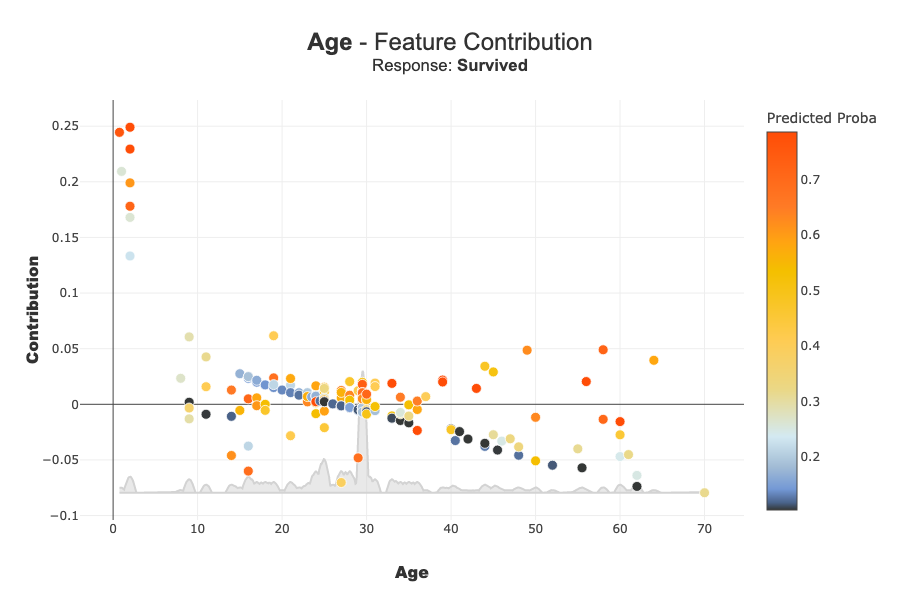

In [10]:
xpl.plot.contribution_plot('Age')

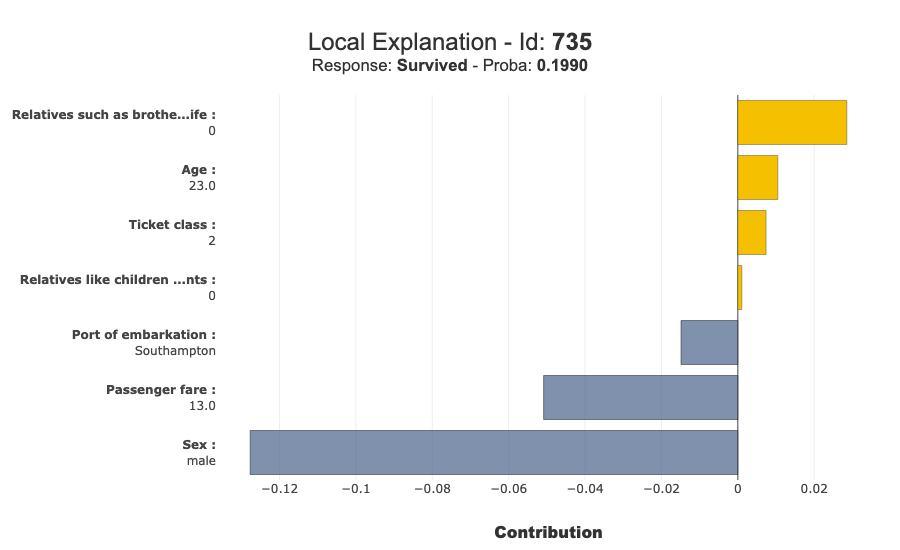

In [11]:
row_id = X_explain.index[0]
xpl.plot.local_plot(index=row_id)

In [12]:
xpl.to_pandas(max_contrib=8).head(10)

,Survived,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2,feature_3,value_3,contribution_3,...,contribution_4,feature_5,value_5,contribution_5,feature_6,value_6,contribution_6,feature_7,value_7,contribution_7
735,Deceased,Sex,male,0.127684,Passenger fare,13.0,0.050851,Relatives such as brother or wife,0,-0.028539,...,0.014882,Age,23.0,-0.010472,Ticket class,2,-0.007397,Relatives like children or parents,0,-0.001051
625,Deceased,Sex,male,0.116236,Relatives such as brother or wife,0,-0.028845,Ticket class,3,0.025976,...,0.021563,Age,21.0,-0.017173,Port of embarkation,Southampton,0.014301,Relatives like children or parents,0,-0.000764
104,Deceased,Sex,male,0.125619,Passenger fare,8.65,0.088861,Relatives such as brother or wife,0,-0.025193,...,0.020886,Port of embarkation,Southampton,0.013359,Age,33.0,0.012455,Relatives like children or parents,0,-0.000961
388,Survived,Sex,female,0.286759,Relatives such as brother or wife,0,0.032435,Passenger fare,13.0,-0.023769,...,-0.014274,Ticket class,2,0.011565,Relatives like children or parents,0,0.006016,Age,36.0,0.002935
342,Survived,Sex,female,0.206648,Relatives such as brother or wife,3,-0.121622,Passenger fare,263.0,0.106484,...,0.015445,Port of embarkation,Southampton,-0.010942,Age,24.0,-0.008412,Relatives like children or parents,2,0.005304
352,Deceased,Sex,male,0.115636,Passenger fare,35.0,-0.064915,Ticket class,1,-0.048789,...,-0.031078,Port of embarkation,Southampton,0.011676,Relatives like children or parents,0,-0.004565,Age,29.5,0.002919
367,Survived,Sex,female,0.244876,Passenger fare,75.25,0.170982,Ticket class,1,0.05393,...,0.038142,Age,60.0,-0.01554,Relatives such as brother or wife,1,-0.008888,Relatives like children or parents,0,0.004335
296,Deceased,Sex,male,0.10905,Ticket class,1,-0.045848,Passenger fare,27.72,-0.035266,...,-0.030661,Port of embarkation,Cherbourg,-0.030228,Relatives like children or parents,0,-0.004339,Age,29.5,0.004128
428,Survived,Sex,female,0.242509,Relatives such as brother or wife,0,0.040903,Passenger fare,26.0,0.026343,...,0.023752,Port of embarkation,Southampton,-0.011517,Ticket class,2,0.011443,Relatives like children or parents,0,0.004754
824,Survived,Sex,female,0.266229,Relatives such as brother or wife,0,0.03253,Passenger fare,12.48,-0.031449,...,-0.025467,Port of embarkation,Southampton,-0.013692,Relatives like children or parents,1,-0.008707,Age,27.0,0.005659


## 8. (Optional) Launch the Shapash WebApp

As in `shapash/webapp/webapp_launch.py`, you can also launch the interactive application:

In [13]:
xpl.init_app()
app = xpl.smartapp.app
app.run_server(host='localhost', port=8050)